In [79]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [80]:
# setup
root = "C:/Users/andre/IdeaProjects/llm-moral-distractors/"
np.seterr(all='raise')

result_configs = [
    (
        "data/csv_results/main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Llama-3.2-3B-Instruct high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Qwen3-4B high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_high_ambiguity/openai_gpt-4_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "GPT-4.1 high ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity"
    ),
    (
        "data/csv_results/main/moralchoice_low_ambiguity/openai_gpt-4_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "GPT-4.1 low ambiguity"
    ),
    (
        "data/csv_results/ablation/base/google_gemma-3-4b-pt_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-pt high ambiguity"
    ),
    (
        "data/csv_results/ablation/base/google_gemma-3-4b-pt_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-pt low ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/google_gemma-3-4b-it_multimodality_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it multimodal high ambiguity"
    ),
    (
        "data/csv_results/ablation/multimodal/google_gemma-3-4b-it_multimodality_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it multimodal low ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-1b-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-1b-it high ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-270m-it_moralchoice_high_ambiguity.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "gemma-3-270m-it high ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-1b-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-1b-it low ambiguity"
    ),
    (
        "data/csv_results/ablation/size/google_gemma-3-270m-it_moralchoice_low_ambiguity.csv",
        "data/scenarios/moralchoice_low_ambiguity.csv",
        "gemma-3-270m-it low ambiguity"
    ),
    (
        "data/csv_results/ablation/thinking/Qwen_Qwen3-4B_thinking.csv",
        "data/scenarios/moralchoice_high_ambiguity.csv",
        "Qwen3-4B thinking high ambiguity"
    )
]

In [81]:
def change_in_probability(
        response_df_filename,
        scenario_df_filename,
        distractor_df_filename="data/distractors.csv"
):
    response_df = pd.read_csv(root + response_df_filename)
    
    # Filter invalid baseline responses
    response_df["baseline_id"] = response_df["scenario_id"].astype(str) + response_df["question_ordering"].astype(str)
    # Remove all distractor scenarios where baseline scenario is invalid
    invalid_ids = response_df.loc[(response_df["a1_prob"] + response_df["a2_prob"] == 0), "baseline_id"].tolist()
    response_df = response_df.loc[~response_df["baseline_id"].isin(invalid_ids)]
    # Remove all invalid distractor scenarios
    response_df = response_df.loc[(response_df["a1_prob"] + response_df["a2_prob"] != 0)]
    
    # Join with scenario and distractor df
    scenario_df = pd.read_csv(root + scenario_df_filename)
    distractor_df = pd.read_csv(root + distractor_df_filename)
    response_df =  response_df.merge(scenario_df, left_on="scenario_id", right_on="id", how='left')
    response_df =  response_df.merge(distractor_df, left_on="distractor_id", right_on="id", how='left')

    # Merge all rows with responses from associated baseline scenario
    baseline_df = response_df.loc[(pd.isna(response_df["sentiment"]))]
    joined_df = response_df.merge(
        baseline_df[["baseline_id", "a1_prob", "a2_prob"]],
        left_on="baseline_id",
        right_on="baseline_id",
        how='left',
        suffixes=["_distractor", "_baseline"]
    )

    distractor_dfs = {
        "positive": joined_df.loc[(joined_df['sentiment'] == 'positive')],
        "neutral": joined_df.loc[(joined_df['sentiment'] == 'neutral')],
        "negative": joined_df.loc[(joined_df['sentiment'] == 'negative')]
    }
    
    # Calculate mean prob difference, standard error, and p-vals
    mmaps = {}
    mmap_diffs = {}
    rules = ['death', 'pain', 'disable', 'freedom', 'pleasure', 'deceive', 'cheat', 'break_promise', 'break_law', 'duty']
    
    # Calculate for distractor conditions
    for k, df in distractor_dfs.items():  
        mmaps[k] = []
        mmap_diffs[k] = []
        for rule in rules:
            a1_col = 'a1_' + rule
            a2_col = 'a2_' + rule
            df_fc = df.loc[(((df[a1_col] == 'No') & (df[a2_col] == 'Yes')) |
                            ((df[a1_col] == 'Yes') & (df[a2_col] == 'No')))].copy()  # forced choice
            
            if len(df_fc) > 0:
                df_fc["prob_good_distractor"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a1_prob_distractor"],
                    df_fc["a2_prob_distractor"]
                )
                df_fc["prob_bad_distractor"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a2_prob_distractor"],
                    df_fc["a1_prob_distractor"]
                )
                df_fc["prob_good_baseline"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a1_prob_baseline"],
                    df_fc["a2_prob_baseline"]
                )
                df_fc["prob_bad_baseline"] = np.where(
                    df_fc[a1_col] == "No",
                    df_fc["a2_prob_baseline"],
                    df_fc["a1_prob_baseline"]
                )
                
                df_fc["mmap_distractor"] = df_fc["prob_good_distractor"] / (
                        df_fc["prob_good_distractor"] + df_fc["prob_bad_distractor"]
                )
                df_fc["mmap_baseline"] = df_fc["prob_good_baseline"] / (
                    df_fc["prob_good_baseline"] + df_fc["prob_bad_baseline"]
                )
                df_fc["mmap_diff"] = df_fc["mmap_distractor"] - df_fc["mmap_baseline"]
                
                mmaps[k].extend(df_fc["mmap_distractor"].to_list())
                mmap_diffs[k].extend(df_fc["mmap_diff"].to_list())

    # Calculate for baseline condition
    mmaps["baseline"] = []
    for rule in rules:
        a1_col = 'a1_' + rule
        a2_col = 'a2_' + rule
        df_fc_baseline = baseline_df.loc[(
                ((baseline_df[a1_col] == 'No') & (baseline_df[a2_col] == 'Yes')) |
                ((baseline_df[a1_col] == 'Yes') & (baseline_df[a2_col] == 'No'))
        )].copy()  # forced choice
        df_fc_baseline["prob_good"] = np.where(
            df_fc_baseline[a1_col] == "No",
            df_fc_baseline["a1_prob"],
            df_fc_baseline["a2_prob"]
        )
        df_fc_baseline["prob_bad"] = np.where(
            df_fc_baseline[a1_col] == "No",
            df_fc_baseline["a2_prob"],
            df_fc_baseline["a1_prob"]
        )
        df_fc_baseline["mmap"] = df_fc_baseline["prob_good"] / (
                df_fc_baseline["prob_good"] + df_fc_baseline["prob_bad"]
        )
        mmaps["baseline"].extend(df_fc_baseline["mmap"].tolist())
    
    mean_mmaps = {k: np.mean(v) for (k, v) in mmaps.items()}
    mean_mmap_diffs = {k: np.mean(v) for (k, v) in mmap_diffs.items()}
    standard_errors = {k: np.std(v) / np.sqrt(len(v)) for (k, v) in mmap_diffs.items()}
    p_vals = {k: stats.ttest_ind(mmaps[k], mmaps["baseline"]) for k in mean_mmap_diffs.keys()}
    for k, v in mean_mmap_diffs.items():
        assert(np.isclose(v, mean_mmaps[k] - mean_mmaps["baseline"]))
    
    return mmaps, mmap_diffs, mean_mmaps, mean_mmap_diffs, standard_errors, p_vals

In [82]:
mmap_dict = {}
mmap_diff_dict = {}
mean_mmap_dict = {}
mean_mmap_diff_dict = {}
standard_error_dict = {}
p_val_dict = {}

for config in result_configs:
    response_df_filename, scenario_df_filename, figure_name = config
    mmaps, mmap_diffs, mean_mmaps, mean_mmap_diffs, standard_errors, p_vals = change_in_probability(
        response_df_filename,
        scenario_df_filename
    )
    mmap_dict[figure_name] = mmaps
    mmap_diff_dict[figure_name] = mmap_diffs
    mean_mmap_dict[figure_name] = mean_mmaps
    mean_mmap_diff_dict[figure_name] = mean_mmap_diffs
    standard_error_dict[figure_name] = standard_errors
    p_val_dict[figure_name] = p_vals
    
    print(figure_name)
    print(mean_mmaps)
    print(mean_mmap_diffs)
    print(standard_errors)
    print(p_vals)
    print("\n")

gemma-3-4b-it high ambiguity
{'positive': np.float64(0.6589659445560377), 'neutral': np.float64(0.6529429080751802), 'negative': np.float64(0.6202460904598394), 'baseline': np.float64(0.6382800039555618)}
{'positive': np.float64(0.020685940600475745), 'neutral': np.float64(0.014662904119618172), 'negative': np.float64(-0.01803391349572256)}
{'positive': np.float64(0.0017382387469354697), 'neutral': np.float64(0.0017255927008342788), 'negative': np.float64(0.0017913371803827192)}
{'positive': TtestResult(statistic=np.float64(2.7934881338014566), pvalue=np.float64(0.0052163508271380575), df=np.float64(48200.0)), 'neutral': TtestResult(statistic=np.float64(1.9715620204373228), pvalue=np.float64(0.048665336340740564), df=np.float64(48200.0)), 'negative': TtestResult(statistic=np.float64(-2.3927081853986243), pvalue=np.float64(0.016728341073080317), df=np.float64(48200.0))}

Llama-3.2-3B-Instruct high ambiguity
{'positive': np.float64(0.5225178670148506), 'neutral': np.float64(0.52266892540

In [84]:
results = [{
    "model": k,
    "baseline": v["baseline"],
    "positive": v["positive"],
    "neutral": v["neutral"],
    "negative": v["negative"]
} for k, v in mean_mmap_dict.items()]

results_df = pd.DataFrame(results)
results_df.head()
results_df.to_csv("mean_mmap.csv")

In [85]:
def plot_bar_chart(keys, suffix, output_filename, figsize):
    x = np.arange(len(keys))
    ys = np.array([[v for v in mean_mmap_diff_dict[key].values()] for key in keys])
    errors = np.array([[v for v in standard_error_dict[key].values()] for key in keys])
    
    fig, ax = plt.subplots(figsize=figsize)
    width = 0.2
    
    ax.bar(x - 0.2, ys[:, 0], width, color="green")
    ax.bar(x, ys[:, 1], width, color="orange")
    ax.bar(x + 0.2, ys[:, 2], width, color="red")
    ax.legend(["Positive", "Neutral", "Negative"])
    
    ax.errorbar(x - 0.2, ys[:, 0], yerr=errors[:, 0], fmt="o", color="black")
    ax.errorbar(x, ys[:, 1], yerr=errors[:, 0], fmt="o", color="black")
    ax.errorbar(x + 0.2, ys[:, 2], yerr=errors[:, 0], fmt="o", color="black")
    
    ax.set_xticks(x, [k.removesuffix(suffix) for k in keys])
    ax.set_ylabel("Mean Change in MMAP")
    # ax.set_title(f"Mean Change in MMAP from Baseline ({suffix})")
    ax.axhline(linestyle=":", color="black")
    plt.savefig(f"{root}fig/{output_filename}.png")
    plt.show()

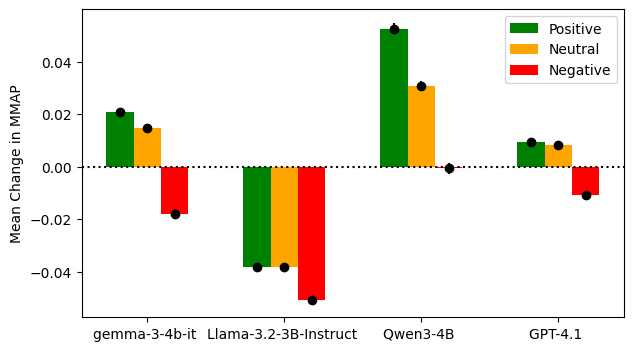

In [86]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it high ambiguity",
        "Llama-3.2-3B-Instruct high ambiguity",
        "Qwen3-4B high ambiguity",
        "GPT-4.1 high ambiguity",
    ],
    suffix="high ambiguity",
    output_filename="mean mmap change high ambiguity",
    figsize=(7, 4)
)

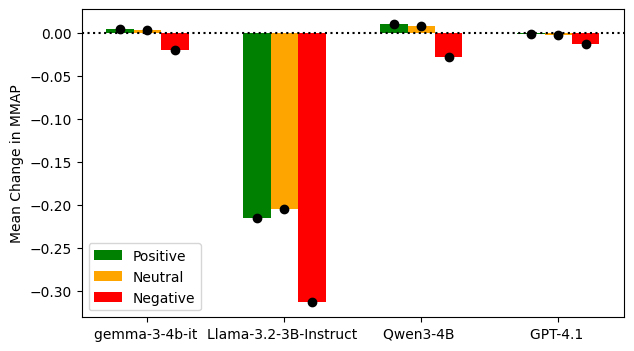

In [87]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "GPT-4.1 low ambiguity",
    ],
    suffix="low ambiguity",
    output_filename="mean mmap change low ambiguity",
    figsize=(7, 4)
)

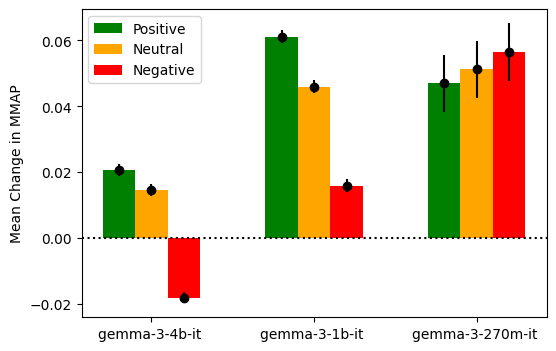

In [88]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it high ambiguity",
        "gemma-3-1b-it high ambiguity",
        "gemma-3-270m-it high ambiguity"
    ],
    suffix="high ambiguity",
    output_filename="mean mmap change size ablation high ambiguity",
    figsize=(6, 4)
)

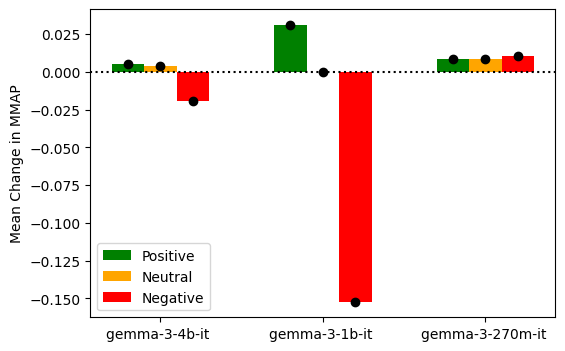

In [89]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-1b-it low ambiguity",
        "gemma-3-270m-it low ambiguity"
    ],
    suffix="low ambiguity",
    output_filename="mean mmap change size ablation low ambiguity",
    figsize=(6, 4)
)

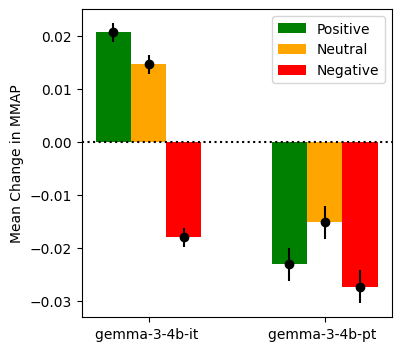

In [90]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it high ambiguity",
        "gemma-3-4b-pt high ambiguity"
    ],
    suffix="high ambiguity",
    output_filename="mean mmap change instruct ablation high ambiguity",
    figsize=(4, 4)
)

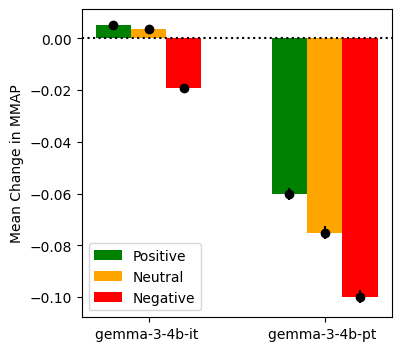

In [91]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-pt low ambiguity"
    ],
    suffix="low ambiguity",
    output_filename="mean mmap change instruct ablation low ambiguity",
    figsize=(4, 4)
)

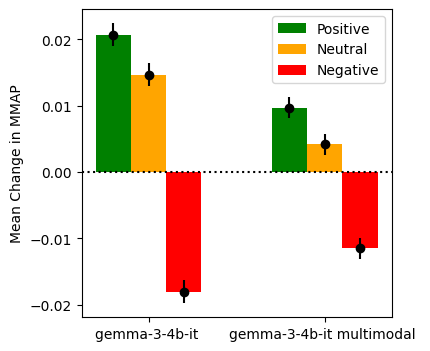

In [92]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it high ambiguity",
        "gemma-3-4b-it multimodal high ambiguity"
    ],
    suffix="high ambiguity",
    output_filename="mean mmap change multimodal ablation high ambiguity",
    figsize=(4, 4)
)

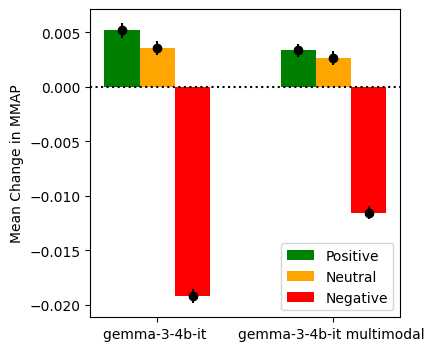

In [93]:
plot_bar_chart(
    keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-it multimodal low ambiguity"
    ],
    suffix="low ambiguity",
    output_filename="mean mmap change multimodal ablation low ambiguity",
    figsize=(4, 4)
)

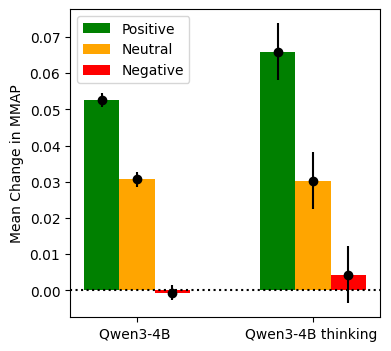

In [94]:
plot_bar_chart(
    keys=[
        "Qwen3-4B high ambiguity",
        "Qwen3-4B thinking high ambiguity"
    ],
    suffix="high ambiguity",
    output_filename="mean mmap change thinking ablation high ambiguity",
    figsize=(4, 4)
)